# Mô hình TabM với Nhãn Giả

Tham khảokhảo: https://www.kaggle.com/code/cdeotte/first-place-single-model-lb-38-81

Tôi đã thực hiện một số thay đổi nhỏ và cải thiện chất lượng:

- Chuyển đổi sang tập dữ liệu của cuộc thi này
- Cho phép các fold khác nhau (vào/ra)
- Lưu tất cả các bài kiểm tra cho mỗi fold
- Lấy tầm quan trọng trung bình của các đặc trưng để vẽ biểu đồ (thay vì mô hình cuối cùng)

- Cho phép sử dụng nhãn giả
- Sử dụng `TargetEncoder` từ `sklearn` để tính xác suất trung bình (cho phép linh hoạt hơn trong việc xử lý các giá trị thiếu/toàn cục)

## Nhật ký thay đổi

- V3: Thêm các combo chọn -> cần được nghiên cứu thêm
- V5: Thêm `std` vào bản gốc

In [1]:
!pip install pytabkit 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 9.0 MB/s eta 0:00:00


In [2]:
NAME = '001'

In [3]:
from sklearn.metrics import roc_auc_score, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import KFold
from sklearn.preprocessing import TargetEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
import seaborn as sns

In [4]:
from pytabkit import TabM_D_Classifier

In [5]:
# %load_ext cudf.pandas

import numpy as np, pandas as pd, gc
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 200)

In [ ]:
train_file = '/kaggle/input/competitions/playground-series-s6e3/train.csv'
test_file = '/kaggle/input/competitions/playground-series-s6e3/test.csv'
original_file = '/kaggle/input/datasets/cdeotte/s6e3-original-dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv'

train = pd.read_csv(train_file)
test = pd.read_csv(test_file)
orig = pd.read_csv(original_file)

train_ids = train['id'].copy()
test_ids = test['id'].copy() # submission

In [7]:
train['Churn'] = train['Churn'].map({'No': 0, 'Yes': 1})
orig['Churn'] = orig['Churn'].map({'No': 0, 'Yes': 1})

In [8]:
_tc = pd.to_numeric(orig.TotalCharges, errors='coerce')
_tc[_tc.isnull()] = orig[_tc.isnull()].MonthlyCharges * orig[_tc.isnull()].tenure
orig.TotalCharges = _tc

In [9]:
test.columns.shape

(20,)

In [10]:
train.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]
print(f"There are {len(CATS)} categorical columns:")
print(CATS)

NUMS = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(f"There are {len(NUMS)} numerical columns:")
print(NUMS)

There are 15 categorical columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
There are 3 numerical columns:
['tenure', 'MonthlyCharges', 'TotalCharges']


# Feature Engineering

In [12]:
NEW_NUMS = []
NEW_CATS = []
NUM_AS_CAT = []
TO_REMOVE = []
NON_TE_CATS = []

In [ ]:
# Tính tần suất từ ​​TẤT CẢ dữ liệu (huấn luyện + gốc + kiểm tra)
for cat in NUMS:
    freq = pd.concat([train[cat], orig[cat], test[cat]]).value_counts(normalize=True)
    for df in [train, test, orig]:
        df[f'FREQ_{cat}'] = df[cat].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{cat}')

In [ ]:
#nguồnnguồn: https://www.kaggle.com/code/datasciencegrad/s6e3-detail-eda-baseline-xgb-auc-0-91808?scriptVersionId=300750597
# Tương tác số học - các đặc trưng số học trong tập dữ liệu huấn luyện
for df in [train, test, orig]:
    # Đã loại bỏ sự khác biệt ở đây vì XGB chỉ quan tâm đến thứ tự
    df['charges_deviation']      = (df['tenure'] * df['MonthlyCharges']).astype('float32')
    df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1)).astype('float32')
    df['avg_monthly_charges']    = (df['TotalCharges'] / (df['tenure'] + 1)).astype('float32')

NEW_NUMS += ['charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges']

# Số lượng dịch vụ + cờ nhị phân
SERVICE_COLS = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for df in [train, test, orig]:
    df['service_count'] = (df[SERVICE_COLS] == 'Yes').sum(axis=1).astype('float32')
    # đã xóa các cờ nhị phân - cây có thể ánh xạ chúng rồi

NEW_NUMS += ['service_count']

In [ ]:
# numerical as categorical
for col in NUMS:    
    _new_col = f'CAT_{col}'
    NUM_AS_CAT.append(_new_col)

    for df in [train, test, orig]:
        df[_new_col] = df[col].astype(str).astype('category')

In [16]:
train.isna().any().any(), test.isna().any().any()

(np.False_, np.False_)

In [17]:
for col in CATS:
    stats = orig.groupby(col)['Churn'].agg(['mean', 'std']).reset_index()
    stats.columns = [col] + [f"ORIG_{col}_{s}" for s in ['mean', 'std']]

    train = train.merge(stats, on=col, how='left')
    test = test.merge(stats, on=col, how='left')

    fill_values = {
        f"ORIG_{col}_mean": 0.5,
        f"ORIG_{col}_std": 0,
    }
    train = train.fillna(value=fill_values)
    test = test.fillna(value=fill_values)

    NEW_NUMS.extend([f"ORIG_{col}_{s}" for s in ['mean', 'std']])

In [18]:
FEATURES = NUMS + CATS + NEW_NUMS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS
print(f'We now have {len(FEATURES)} columns:')
print(FEATURES)

We now have 58 columns:
['tenure', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'FREQ_tenure', 'FREQ_MonthlyCharges', 'FREQ_TotalCharges', 'charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges', 'service_count', 'ORIG_gender_mean', 'ORIG_gender_std', 'ORIG_SeniorCitizen_mean', 'ORIG_SeniorCitizen_std', 'ORIG_Partner_mean', 'ORIG_Partner_std', 'ORIG_Dependents_mean', 'ORIG_Dependents_std', 'ORIG_PhoneService_mean', 'ORIG_PhoneService_std', 'ORIG_MultipleLines_mean', 'ORIG_MultipleLines_std', 'ORIG_InternetService_mean', 'ORIG_InternetService_std', 'ORIG_OnlineBackup_mean', 'ORIG_OnlineBackup_std', 'ORIG_DeviceProtection_mean', 'ORIG_DeviceProtection_std', 'ORIG_TechSupport_mean', 'ORIG_TechSupport_std', 'ORIG_StreamingTV_mean', 'ORIG_StreamingTV_std'

In [ ]:
# THỐNG KÊ MÃ HÓA MỤC TIÊU ĐỂ TỔNG HỢP CHO CÁC NHÓM ĐẶC TRƯNG CỦA CHÚNG TA
STATS = ['std'] # Giá trị trung bình là xác suất, được xử lý bởi TargetEncoder

TE_COLUMNS = NUM_AS_CAT + CATS + NEW_CATS
TO_REMOVE += NUM_AS_CAT + CATS + NEW_CATS
QUANTILE_COLUMNS = []

# Model Training

In [20]:
np.random.seed(11)

In [21]:
PSEUDO_LABELS = True
TRES = 0.999

FOLDS = 5
INNER_FOLDS = 5

In [22]:
# tabm_params = {
#     'device': 'cuda',
#     'random_state': 100,
#     'verbosity': 0,
#     'arch_type': 'tabm-normal',
#     'tabm_k': 24,
#     'num_emb_type': 'pwl',
#     'd_embedding': 16, 
#     'batch_size': 128, 
#     'lr': 1e-3, 
#     'n_epochs': 100,
#     'dropout': 0.11,
#     'd_block': 128, 
#     'n_blocks': 10,
#     'patience': 4,
#     'weight_decay': 1e-2,
# }

tabm_params = {
     'device': 'cuda', 
     'batch_size': 'auto',
     'patience': 16,
     'allow_amp': True,
     'arch_type': 'tabm-mini',
     'tabm_k': 8,
     'gradient_clipping_norm': 1.0, 
     'share_training_batches': False,
     'lr': 1e-3,
     'weight_decay': 1e-3,
     'n_blocks': 3,
     'd_block': 512, 
     'dropout': 0.0, 
     'num_emb_type': 'pwl',
     'd_embedding': 32,
     'num_emb_n_bins': 119,
}

In [23]:
import warnings
warnings.simplefilter('ignore')

# Model Training

In [ ]:
%%time

print(f"\n{'='*80}")
print("TRAINING TABM")
print("="*80)

kf = KFold(n_splits=FOLDS, shuffle=True, random_state=11)

oof = np.zeros((len(train)))
pred = np.zeros((len(test)))
importances = []
roc_auc_folds = []
pred_per_fold = []


for i, (train_index, val_index) in enumerate(kf.split(train)):
    print(f"\nFold {i+1}/{FOLDS}")

    # ===================================
    # TRAIN/VAL SPLIT
    # ===================================
    X_train = train.loc[train_index,FEATURES+['Churn']].reset_index(drop=True).copy()
    y_train = train.loc[train_index,'Churn']
    
    X_val = train.loc[val_index,FEATURES].reset_index(drop=True).copy()
    y_val = train.loc[val_index,'Churn']

    X_train = pd.concat([X_train],axis=0).reset_index(drop=True).copy()
    y_train = np.concatenate([y_train],axis=0).copy()
    

    X_test = test[FEATURES].reset_index(drop=True).copy()

    # ===================================
    # INNER K FOLD (ĐỂ NGĂN NGỪA RÒ RỈ KHI SỬ DỤNG TARGET)
    # ===================================
    kf2 = KFold(n_splits=INNER_FOLDS, shuffle=True, random_state=11)
    
    for j, (train_index2, val_index2) in enumerate(kf2.split(X_train)):
        print(f" ## INNER Fold {j+1} (outer fold {i+1}) ##")

        X_train2 = X_train.loc[train_index2, FEATURES + ['Churn']].copy()
        X_val2   = X_train.loc[val_index2, FEATURES].copy()
        y_train2 = y_train[train_index2]
        y_val2   = y_train[val_index2]
        

        # ===================================
        # TARGET ENCODING/AGGREGATION
        # ===================================
    
        ### FEATURE SET 1 (dùngdùng exam_score) ###
        for col in TE_COLUMNS:
        # col = 'study_hours'
            tmp = X_train2.groupby(col, observed=False)['Churn'].agg(STATS)
            tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
            X_val2 = X_val2.merge(tmp, on=col, how="left") # đây là các dự đoán oof
        
            for c in tmp.columns:
                X_train.loc[val_index2, c] = X_val2[c].values.astype("float32")

        # ===================================
        # END TARGET ENCODING/AGGREGATION
        # ===================================

    
    ### FEATURE SET 1 (dùng Churn) ###
    for col in TE_COLUMNS:
        tmp = X_train.groupby(col, observed=False)['Churn'].agg(STATS)
        tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
        tmp = tmp.astype("float32")
        X_val = X_val.merge(tmp, on=col, how="left")
        X_test = X_test.merge(tmp, on=col, how="left")

    
        X_train[[f"TE1_{col}_{s}" for s in STATS]] = X_train[[f"TE1_{col}_{s}" for s in STATS]].fillna(0)
        X_val[[f"TE1_{col}_{s}" for s in STATS]] = X_val[[f"TE1_{col}_{s}" for s in STATS]].fillna(0)
        X_test[[f"TE1_{col}_{s}" for s in STATS]] = X_test[[f"TE1_{col}_{s}" for s in STATS]].fillna(0)
        
    
    NEW_COL_NAMES = [f'TE_{col}' for col in TE_COLUMNS]
    target_encoder = TargetEncoder(cv=INNER_FOLDS, shuffle=True, smooth='auto', target_type='binary', random_state=11)
    
    X_train[NEW_COL_NAMES] = target_encoder.fit_transform(X_train[TE_COLUMNS], y_train)
    X_val[NEW_COL_NAMES] = target_encoder.transform(X_val[TE_COLUMNS])
    X_test[NEW_COL_NAMES] = target_encoder.transform(X_test[TE_COLUMNS])

    # ===================================
    # END INNER KFold mã hóa mục tiêu
    # ===================================

    # ===================================    
    # TÁCH CÁC CÓ TRƯNG THÀI ĐẠI HÀM MÃ HÓA MỤC TIÊU
    X_train[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS] = X_train[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS].astype(str).astype("category")
    X_val[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS] = X_val[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS].astype(str).astype("category")
    X_test[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS] = X_test[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS].astype(str).astype("category")

    X_train.drop(TO_REMOVE, axis=1, inplace=True)
    X_val.drop(TO_REMOVE, axis=1, inplace=True)
    X_test.drop(TO_REMOVE, axis=1, inplace=True)

 
    X_train = X_train.drop(['Churn'],axis=1)
    COLS = X_train.columns
    
    # ===================================
    # train TABM
    # ===================================

    model = TabM_D_Classifier(**tabm_params) 
    model.fit(X_train.values, y_train, X_val.values, y_val.values)

    if PSEUDO_LABELS:

        oof_preds = model.predict_proba(X_val.values)[:,1]
        test_preds = model.predict_proba(X_test.values)[:,1]
    
        X_train_model1 = pd.concat([
            X_train,
            X_test[(test_preds > TRES) | (test_preds < 1 - TRES)]
        ], axis=0)
        
        y_train_model1 = np.concatenate([
            y_train,
            (test_preds[(test_preds > TRES) | (test_preds < 1 - TRES)] > 0.5).astype(int)
        ], axis=0)
    
        roc_auc_model1 = roc_auc_score(y_val, oof_preds)
    
        print('Training tabm 2')
        # TRAIN MODEL WITH PSEUDO LABELS
        model2 = TabM_D_Classifier(**tabm_params) 
        model2.fit(X_train.values, y_train, X_val.values, y_val.values)
        
        oof_preds2 = model2.predict_proba(X_val.values)[:,1]
        roc_auc_model2 = roc_auc_score(y_val, oof_preds2)
    
        if roc_auc_model2 > roc_auc_model1:
            print(f'Pseudo labels improvement: {roc_auc_model1} to {roc_auc_model2}')
            model = model2
            oof_preds = oof_preds2
        else:
            print(f'NO pseudo labels improvement: {roc_auc_model1} to {roc_auc_model2}')



    # ===================================
    # dự đoánđoán OOF and TEST
    # ===================================
    
    oof[val_index] = model.predict_proba(X_val.values)[:,1]
    roc_auc_fold = roc_auc_score(y_val, oof[val_index])
    roc_auc_folds.append(roc_auc_fold)
    print(f"Validation ROC AUC: {roc_auc_fold:.5f}")

    pred += (_test_preds := model.predict_proba(X_test[COLS].values)[:,1])
    pred_per_fold.append(_test_preds)
    
    # CLEAR MEMORY
    del X_train, X_val, X_test
    del y_train, y_val
    if i != FOLDS-1: del model
    gc.collect()

pred /= FOLDS


TRAINING TABM

Fold 1/5
 ## INNER Fold 1 (outer fold 1) ##
 ## INNER Fold 2 (outer fold 1) ##
 ## INNER Fold 3 (outer fold 1) ##
 ## INNER Fold 4 (outer fold 1) ##
 ## INNER Fold 5 (outer fold 1) ##
Training tabm 2
Pseudo labels improvement: 0.9175060410103422 to 0.9176333338119098
Validation ROC AUC: 0.91763

Fold 2/5
 ## INNER Fold 1 (outer fold 2) ##
 ## INNER Fold 2 (outer fold 2) ##
 ## INNER Fold 3 (outer fold 2) ##
 ## INNER Fold 4 (outer fold 2) ##
 ## INNER Fold 5 (outer fold 2) ##
Training tabm 2
NO pseudo labels improvement: 0.9186907500733574 to 0.9184510938531165
Validation ROC AUC: 0.91869

Fold 3/5
 ## INNER Fold 1 (outer fold 3) ##
 ## INNER Fold 2 (outer fold 3) ##
 ## INNER Fold 3 (outer fold 3) ##
 ## INNER Fold 4 (outer fold 3) ##
 ## INNER Fold 5 (outer fold 3) ##
Training tabm 2
NO pseudo labels improvement: 0.9180971665166408 to 0.9180070567602938
Validation ROC AUC: 0.91810

Fold 4/5
 ## INNER Fold 1 (outer fold 4) ##
 ## INNER Fold 2 (outer fold 4) ##
 ## INNE

In [25]:
print(f'Fold ROC AUC {np.mean(roc_auc_folds):.5f} +- {np.std(roc_auc_folds):.5f}')

true = train['Churn'].values
print(f'Overall ROC AUC: {roc_auc_score(true, oof)}')

Fold ROC AUC 0.91808 +- 0.00053
Overall ROC AUC: 0.9178908634726604


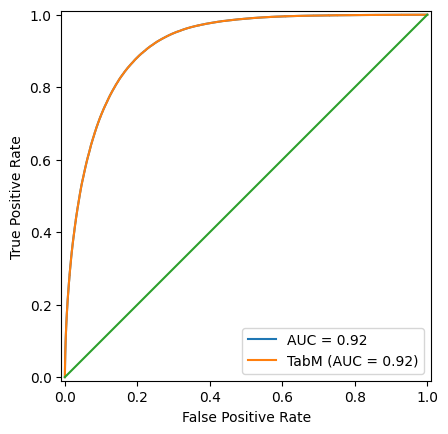

In [26]:
fig, ax = plt.subplots()

fpr, tpr, thresholds = roc_curve(train['Churn'], oof)
roc_auc = auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot(ax=ax)
display.plot(ax=ax, name='TabM')

plt.plot([0., 1.], [0., 1.])
plt.show()

In [27]:
print(f'\nIn total, we used {len(COLS)} features, Wow!\n')
print(list(COLS))


In total, we used 76 features, Wow!

['tenure', 'MonthlyCharges', 'TotalCharges', 'FREQ_tenure', 'FREQ_MonthlyCharges', 'FREQ_TotalCharges', 'charges_deviation', 'monthly_to_total_ratio', 'avg_monthly_charges', 'service_count', 'ORIG_gender_mean', 'ORIG_gender_std', 'ORIG_SeniorCitizen_mean', 'ORIG_SeniorCitizen_std', 'ORIG_Partner_mean', 'ORIG_Partner_std', 'ORIG_Dependents_mean', 'ORIG_Dependents_std', 'ORIG_PhoneService_mean', 'ORIG_PhoneService_std', 'ORIG_MultipleLines_mean', 'ORIG_MultipleLines_std', 'ORIG_InternetService_mean', 'ORIG_InternetService_std', 'ORIG_OnlineBackup_mean', 'ORIG_OnlineBackup_std', 'ORIG_DeviceProtection_mean', 'ORIG_DeviceProtection_std', 'ORIG_TechSupport_mean', 'ORIG_TechSupport_std', 'ORIG_StreamingTV_mean', 'ORIG_StreamingTV_std', 'ORIG_StreamingMovies_mean', 'ORIG_StreamingMovies_std', 'ORIG_Contract_mean', 'ORIG_Contract_std', 'ORIG_PaperlessBilling_mean', 'ORIG_PaperlessBilling_std', 'ORIG_PaymentMethod_mean', 'ORIG_PaymentMethod_std', 'TE1_CAT_t

# Save CSV

In [ ]:

df_oof = pd.DataFrame({'tabm': oof})
df_oof.to_csv(f'{NAME}_oof.csv', index=False)

df_test = pd.DataFrame({'tabm': pred})
df_test.to_csv(f'{NAME}_test.csv',index=False)

df_test = pd.DataFrame({f'fold_{i}': pred for (i, pred) in enumerate(pred_per_fold)})
df_test.to_csv(f'{NAME}_test_per_fold.csv', index=False)

print("Saved oof to file")

Saved oof to file


In [29]:
test.shape

(254655, 60)

In [30]:
sub = pd.DataFrame({
    'id': test['id'],
    'Churn': pred
})

sub.to_csv(f'{NAME}_submission.csv', index=False)